# Lab-2: California Housing Data Preprocessing and Linear Regression
Dataset: California Housing
https://github.com/ageron/handson-ml/blob/master/datasets/housing/housing.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## Load Dataset

In [3]:
url = 'https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv'
df = pd.read_csv(url)
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [4]:
# Data types
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

## Basic Statistics

In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Distribution of Target Variable

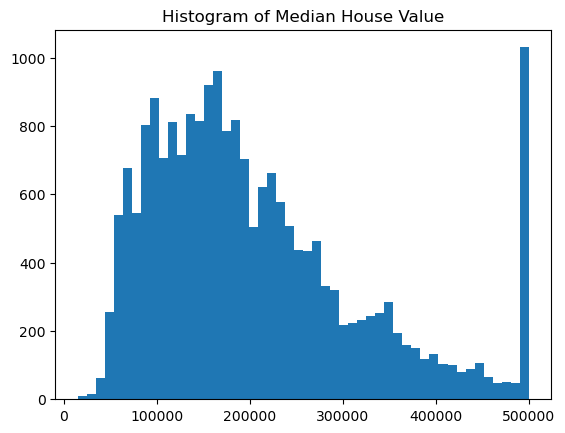

In [6]:
plt.hist(df['median_house_value'], bins=50)
plt.title('Histogram of Median House Value')
plt.show()

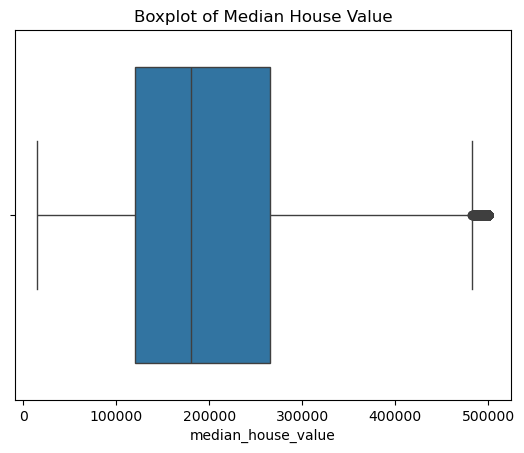

In [7]:
sns.boxplot(x=df['median_house_value'])
plt.title('Boxplot of Median House Value')
plt.show()

## Missing Values

In [8]:
missing_percent = df.isnull().sum() * 100 / len(df)
missing_percent

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

## Handle Missing Values (total_bedrooms)

In [9]:
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

C:\Users\BMSCECSE-SH\AppData\Local\Temp\ipykernel_7936\1590527289.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)


## One-Hot Encoding

In [10]:
df = pd.get_dummies(df, columns=['ocean_proximity'])
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


## MinMax Scaling

In [11]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
scaler = MinMaxScaler(feature_range=(0,1))
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.211155,0.567481,0.784314,0.022331,0.019863,0.008941,0.020556,0.539668,0.902266,False,False,False,True,False
1,0.212151,0.565356,0.392157,0.180503,0.171477,0.067210,0.186976,0.538027,0.708247,False,False,False,True,False
2,0.210159,0.564293,1.000000,0.037260,0.029330,0.013818,0.028943,0.466028,0.695051,False,False,False,True,False
3,0.209163,0.564293,1.000000,0.032352,0.036313,0.015555,0.035849,0.354699,0.672783,False,False,False,True,False
4,0.209163,0.564293,1.000000,0.041330,0.043296,0.015752,0.042427,0.230776,0.674638,False,False,False,True,False


## Stratified Sampling using median_income

In [14]:
df=df.drop_duplicates()

In [17]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [19]:
import numpy as np
from sklearn.model_selection import train_test_split

# Create income category
df['income_cat'] = pd.cut(
    df['median_income'],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1,2,3,4,5],
    include_lowest=True
)

# Check if any NaN exists
print(df['income_cat'].isnull().sum())

# If any NaN exists remove them
df = df.dropna(subset=['income_cat'])

# Stratified split
train_set, test_set = train_test_split(
    df,
    test_size=0.2,
    stratify=df['income_cat'],
    random_state=42
)

# Drop helper column
train_set = train_set.drop("income_cat", axis=1)
test_set = test_set.drop("income_cat", axis=1)

print("Train size:", train_set.shape)
print("Test size:", test_set.shape)

0
Train size: (16512, 14)
Test size: (4128, 14)


## Correlation Matrix

In [20]:
corr_matrix = train_set.corr()
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
longitude,1.000000,-0.924861,-0.111981,0.047739,0.070608,0.102285,0.056796,-0.009710,-0.041830,0.323768,-0.056291,0.009377,-0.477048,0.045720
latitude,-0.924861,1.000000,0.016236,-0.039526,-0.068278,-0.111175,-0.072787,-0.084431,-0.148438,-0.448159,0.351471,-0.016513,0.361440,-0.161745
housing_median_age,-0.111981,0.016236,1.000000,-0.358473,-0.315763,-0.299773,-0.300377,-0.119018,0.107050,0.047515,-0.235052,0.014024,0.257257,0.013893
total_rooms,0.047739,-0.039526,-0.358473,1.000000,0.927485,0.861698,0.919344,0.199796,0.136167,-0.002085,0.021472,-0.008922,-0.025031,-0.002806
total_bedrooms,0.070608,-0.068278,-0.315763,0.927485,1.000000,0.875618,0.972727,-0.003299,0.052382,0.016759,-0.009143,-0.005853,-0.020699,0.007523
population,0.102285,-0.111175,-0.299773,0.861698,0.875618,1.000000,0.911096,0.009006,-0.024618,0.075352,-0.023597,-0.012095,-0.064203,-0.017837
households,0.056796,-0.072787,-0.300377,0.919344,0.972727,0.911096,1.000000,0.016974,0.068976,0.041764,-0.042975,-0.010642,-0.010897,0.008502
median_income,-0.009710,-0.084431,-0.119018,0.199796,-0.003299,0.009006,0.016974,1.000000,0.689752,0.172300,-0.239383,-0.009426,0.054375,0.026544
median_house_value,-0.041830,-0.148438,0.107050,0.136167,0.052382,-0.024618,0.068976,0.689752,1.000000,0.257126,-0.486300,0.022302,0.157825,0.144376
ocean_proximity_<1H OCEAN,0.323768,-0.448159,0.047515,-0.002085,0.016759,0.075352,0.041764,0.172300,0.257126,1.000000,-0.603937,-0.013781,-0.313412,-0.344357


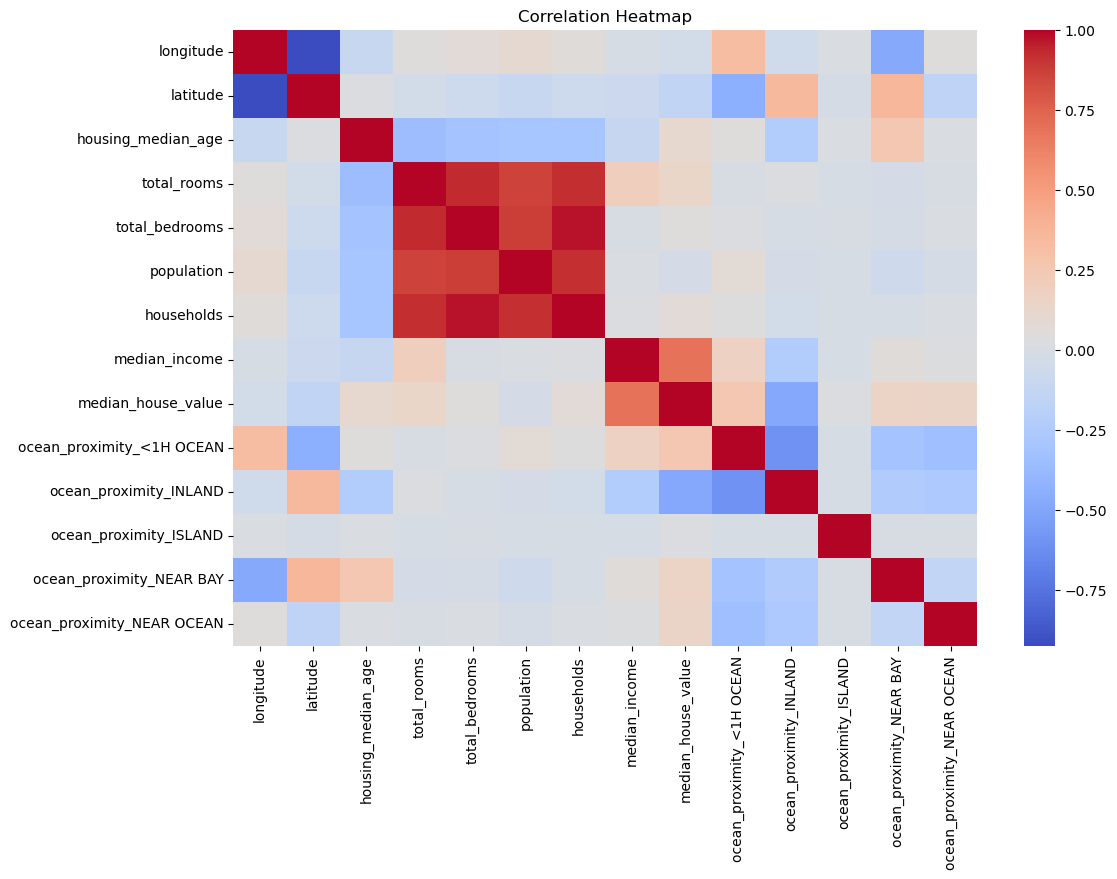

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Scatter Plot

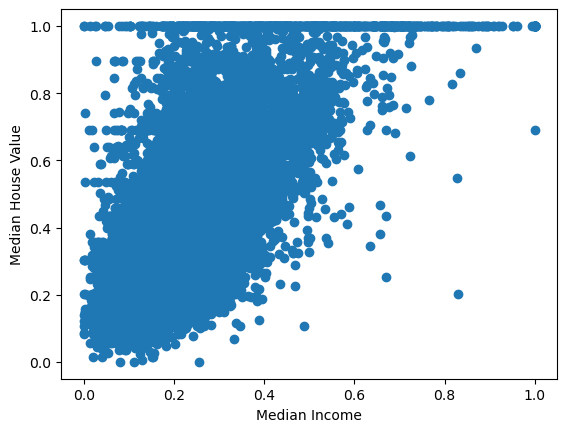

In [22]:
plt.scatter(train_set['median_income'], train_set['median_house_value'])
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

## Random Train-Test Split

In [23]:
train, test = train_test_split(df, test_size=0.2, random_state=42)

## Correlation with Target

In [24]:
corr_target = corr_matrix['median_house_value'].sort_values(ascending=False)
corr_target

median_house_value            1.000000
median_income                 0.689752
ocean_proximity_<1H OCEAN     0.257126
ocean_proximity_NEAR BAY      0.157825
ocean_proximity_NEAR OCEAN    0.144376
total_rooms                   0.136167
housing_median_age            0.107050
households                    0.068976
total_bedrooms                0.052382
ocean_proximity_ISLAND        0.022302
population                   -0.024618
longitude                    -0.041830
latitude                     -0.148438
ocean_proximity_INLAND       -0.486300
Name: median_house_value, dtype: float64

## Standard Scaling

In [25]:
scaler = StandardScaler()

X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

X_scaled = scaler.fit_transform(X)


## Train Linear Regression

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Evaluation Metrics

In [27]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('RMSE:', rmse)
print('MAE:', mae)
print('R2 Score:', r2)

RMSE: 0.1444712229873409
MAE: 0.10450197369012319
R2 Score: 0.6253351959454363
